In [86]:
import os
import sys
from pathlib import Path

# Trova project_root risalendo dall'ubicazione del notebook
current_dir = Path(os.getcwd()).resolve()
project_root = current_dir.parent  # notebooks/ → Computer_Vision_Project/

if not (project_root / '1_Experiment').exists():
    raise FileNotFoundError(
        f"Cartella '1_Experiment' non trovata in: {project_root}\n"
        f"Contenuto trovato: {[p.name for p in project_root.iterdir()]}"
    )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

%load_ext autoreload
%autoreload 2

print(f"✅ project_root: {project_root}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ project_root: C:\Users\ronca\OneDrive\Desktop\Computer Vision\Computer_Vision_Project


In [87]:
from src.data import get_dataloaders
from src.utils import plot_sample_with_annotations

In [88]:
config = {
    'data_dir': str(project_root / '1_Experiment'),
    'box_type': 'standard_box',   # oppure 'rotating_box'
    'batch_size': 1,
    'fold': 0                     # da 0 a 4
}

print(f"📁 data_dir : {config['data_dir']}")
print(f"📦 box_type : {config['box_type']}")
print(f"🔁 fold     : {config['fold']}")
print(f"📊 batch    : {config['batch_size']}")

📁 data_dir : C:\Users\ronca\OneDrive\Desktop\Computer Vision\Computer_Vision_Project\1_Experiment
📦 box_type : standard_box
🔁 fold     : 0
📊 batch    : 1


dls = get_dataloaders(**config)

print(f"✅ Train batches : {len(dls['train'])}")
print(f"✅ Val batches   : {len(dls['val'])}")
print(f"✅ Test batches  : {len(dls['test'])}")

batch_imgs, batch_labels = next(iter(dls['train']))

print(f"Shape immagine : {batch_imgs.shape}")       # [B, C, H, W]
print(f"Chiavi labels  : {list(batch_labels.keys())}")

plot_sample_with_annotations(batch_imgs[0], {
    'classes'  : batch_labels.get('classes',   [[]])[0],
    'boxes'    : batch_labels.get('boxes',     [[]])[0],
    'keypoints': batch_labels.get('keypoints', [[]])[0],
    'angles'   : batch_labels.get('angles',    [[]])[0]
})

batch_imgs_val, batch_labels_val = next(iter(dls['val']))

plot_sample_with_annotations(batch_imgs_val[0], {
    'classes'  : batch_labels_val.get('classes',   [[]])[0],
    'boxes'    : batch_labels_val.get('boxes',     [[]])[0],
    'keypoints': batch_labels_val.get('keypoints', [[]])[0],
    'angles'   : batch_labels_val.get('angles',    [[]])[0]
})

import matplotlib.pyplot as plt

n_samples = 4
fig, axes = plt.subplots(1, n_samples, figsize=(4 * n_samples, 4))

train_iter = iter(dls['train'])
for i in range(n_samples):
    imgs, labels = next(train_iter)
    ax = axes[i]
    ax.set_title(f"Sample {i+1}")
    plot_sample_with_annotations(imgs[0], {
        'classes'  : labels.get('classes',   [[]])[0],
        'boxes'    : labels.get('boxes',     [[]])[0],
        'keypoints': labels.get('keypoints', [[]])[0],
        'angles'   : labels.get('angles',    [[]])[0]
    }, ax=ax)

plt.tight_layout()
plt.show()

In [89]:
dls = get_dataloaders(**config)

print(f"✅ Train batches   : {len(dls['train'])}")
print(f"✅ Test batches    : {len(dls['test'])}")
print(f"✅ Holdout batches : {len(dls['holdout'])}")

[*] Inizializzazione DataLoader - Type: standard_box, Fold: 0, Batch Size: 1
✅ Train batches   : 140
✅ Test batches    : 35
✅ Holdout batches : 17


Shape immagine : torch.Size([1, 1, 128, 128])
Boxes[0] shape : torch.Size([4])


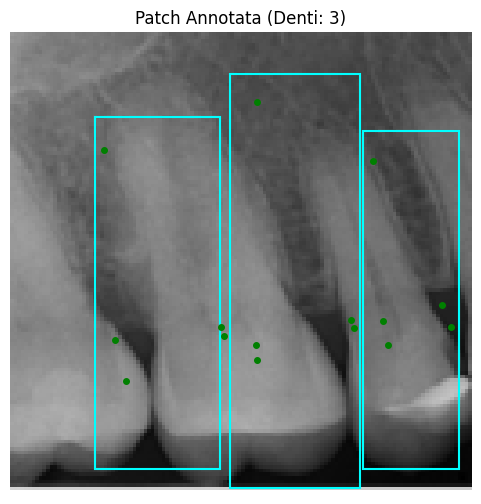

In [90]:
# --- CELLA 5: Sanity Check Train ---
batch_imgs, batch_labels = next(iter(dls['train']))

print(f"Shape immagine : {batch_imgs.shape}")
print(f"Boxes[0] shape : {batch_labels['boxes'][0][0].shape}")  # deve essere torch.Size([4])

plot_sample_with_annotations(batch_imgs[0], {
    'classes'  : batch_labels['classes'][0],
    'boxes'    : batch_labels['boxes'][0],
    'keypoints': batch_labels['keypoints'][0],
    'angles'   : batch_labels['angles'][0]
})

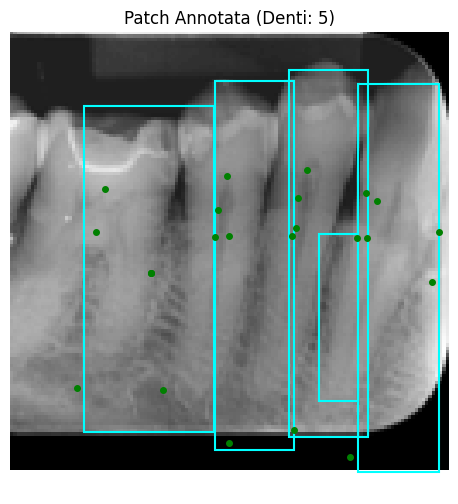

In [91]:
batch_imgs_test, batch_labels_test = next(iter(dls['test']))

plot_sample_with_annotations(batch_imgs_test[0], {
    'classes'  : batch_labels_test.get('classes',   [[]])[0],
    'boxes'    : batch_labels_test.get('boxes',     [[]])[0],
    'keypoints': batch_labels_test.get('keypoints', [[]])[0],
    'angles'   : batch_labels_test.get('angles',    [[]])[0]
})

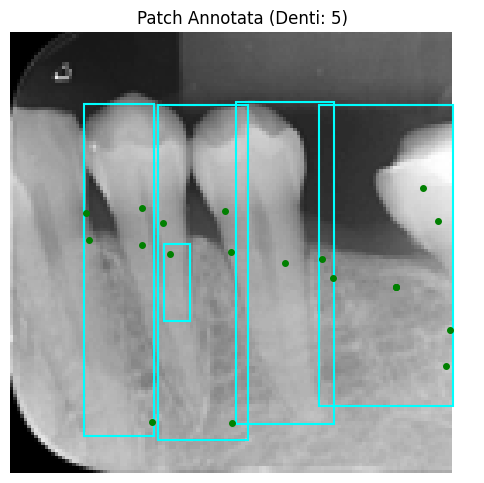

In [92]:
batch_imgs_h, batch_labels_h = next(iter(dls['holdout']))

plot_sample_with_annotations(batch_imgs_h[0], {
    'classes'  : batch_labels_h.get('classes',   [[]])[0],
    'boxes'    : batch_labels_h.get('boxes',     [[]])[0],
    'keypoints': batch_labels_h.get('keypoints', [[]])[0],
    'angles'   : batch_labels_h.get('angles',    [[]])[0]
})